<a href="https://colab.research.google.com/github/HelloJacob11/Double-Moving-Average-Crossover-ML/blob/main/Double_Moving_Average_Crossover_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Improving the 20/50-Day Moving Average Crossover with Machine Learning

**Goal.** This project tests whether a machine learning model, using features such as volatility, RSI, momentum and moving-average ratios, can make better invest-or-cash decisions than the traditional 20/50-day moving average crossover, comparing both on the same out-of-sample periods with the same trading costs, across six ETFs (SPY, QQQ, EFA, IWM, TLT, GLD).

**Setup.** Installs `yfinance` (free Yahoo Finance price data) and imports the libraries used everywhere below: NumPy for math and pandas for tables of dates and prices.

In [2]:
!pip install yfinance          # in Colab
import yfinance as yf
import numpy as np
import pandas as pd

**Download the data.** Daily SPY prices from 2005 to today. Newer versions of `yfinance` return two-level column names, so the `if` line flattens them to `Adj Close`, `Volume`, etc.
`Adj Close` is the closing price adjusted for dividends and splits, so returns over long periods are comparable. All calculations use it.

In [3]:
data = yf.download("SPY", start="2005-01-01", auto_adjust=False)
if isinstance(data.columns,pd.MultiIndex):
  data.columns = data.columns.droplevel(1)
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price       Adj Close       Close        High         Low        Open  \
Date                                                                    
2005-01-03  80.973534  120.300003  121.760002  119.900002  121.559998   
2005-01-04  79.984039  118.830002  120.540001  118.440002  120.459999   
2005-01-05  79.432144  118.010002  119.250000  118.000000  118.739998   
2005-01-06  79.835983  118.610001  119.150002  118.260002  118.440002   
2005-01-07  79.721535  118.440002  119.230003  118.129997  118.970001   

Price         Volume  
Date                  
2005-01-03  55748000  
2005-01-04  69167600  
2005-01-05  65667300  
2005-01-06  47814700  
2005-01-07  55847700  


**Moving averages.** The average closing price over the last 20 days (fast) and the last 50 days (slow). These are the two lines the crossover strategy compares.

In [4]:
data['sma_fast'] = data['Adj Close'].rolling(window=20).mean()   # 20-day SMA
data['sma_slow'] = data['Adj Close'].rolling(window=50).mean()   # 50-day SMA

**EMA version (not used).** Exponential moving averages weight recent days more heavily. Kept commented out as a possible variation.

In [5]:
#data['ema_fast'] = data['Adj Close'].ewm(span=20, adjust=False).mean().  #EMA (saved for later)
#data['ema_slow'] = data['Adj Close'].ewm(span=50, adjust=False).mean()

**Crossover signal.** 1 when the 20-day average is above the 50-day average (be invested), 0 otherwise (hold cash). This one line is the whole traditional strategy.

In [6]:
data['signal'] = (data['sma_fast'] > data['sma_slow']).astype(int)   # 1 = long, 0 = flat

##Double Moving Average Crossover Strategy (Double MA)

**Turning the signal into returns.**
- `position` is the signal moved one day later. The signal is only known at today's close, so the earliest I can act on it is tomorrow. Without this shift the backtest would use information I didn't have yet.
- `ret` is SPY's daily percentage change.
- `strat_ret` is what the strategy earns: SPY's return on days I'm invested, 0 on days in cash.

In [7]:
data['position'] = data['signal'].shift(1)
data['ret'] = data['Adj Close'].pct_change() # 등락
data['strat_ret'] = data['position'] * data['ret'] # 전략 수익률

**Growth of $10,000 (before costs).** Compounds the daily returns for both the strategy and plain buy-and-hold, so they can be plotted in dollars.

In [8]:
capital = 10000
data['Strategy_Value'] = capital * (1 + data['strat_ret']).cumprod()
data['Market_Value'] = capital * (1 + data['ret']).cumprod()

In [9]:
data.head(5)

Price,Adj Close,Close,High,Low,Open,Volume,sma_fast,sma_slow,signal,position,ret,strat_ret,Strategy_Value,Market_Value
Date,,,,,,,,,,,,,,
2005-01-03,80.973534,120.300003,121.760002,119.900002,121.559998,55748000,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
2005-01-04,79.984039,118.830002,120.540001,118.440002,120.459999,69167600,NaN,NaN,0,0.0,-0.012220,-0.0,10000.0,9877.800279
2005-01-05,79.432144,118.010002,119.250000,118.000000,118.739998,65667300,NaN,NaN,0,0.0,-0.006900,-0.0,10000.0,9809.642806
2005-01-06,79.835983,118.610001,119.150002,118.260002,118.440002,47814700,NaN,NaN,0,0.0,0.005084,0.0,10000.0,9859.515782
2005-01-07,79.721535,118.440002,119.230003,118.129997,118.970001,55847700,NaN,NaN,0,0.0,-0.001434,-0.0,10000.0,9845.381714


In [10]:
data.tail(5)

Price,Adj Close,Close,High,Low,Open,Volume,sma_fast,sma_slow,signal,position,ret,strat_ret,Strategy_Value,Market_Value
Date,,,,,,,,,,,,,,
2026-09-30,762.630005,762.630005,769.409973,762.179993,766.450012,62110000,764.023892,761.194248,1,1.0,-0.002054,-0.002054,34057.220934,94182.626185
2026-10-01,763.989990,763.989990,765.650024,758.789978,764.359985,47708100,764.060159,761.562876,1,1.0,0.001783,0.001783,34117.954607,94350.580490
2026-10-02,769.640015,769.640015,772.650024,767.150024,770.580017,46335300,763.979419,762.228646,1,1.0,0.007395,0.007395,34370.271102,95048.342359
2026-10-05,774.830017,774.830017,776.609985,769.630005,769.690002,44840200,764.306808,762.983254,1,1.0,0.006743,0.006743,34602.044122,95689.292828
2026-10-06,779.090027,779.090027,781.619995,777.960022,778.150024,36017885,765.058176,763.819869,1,1.0,0.005498,0.005498,34792.285908,96215.391860


###Analysis of Double MA Strategy

**Chart: Double MA vs Buy & Hold.**

**Buy & Hold earns more overall.** $10,000$ grows to about $95,000$ with buy-and-hold, versus about $34,000$ with the crossover (before costs). When the market rises steadily, as it did for most of 2012–2026, staying fully invested wins. The crossover keeps switching to cash after small dips and buys back in only after the price has already recovered, so it misses part of every rally.

**The Double MA is steadier and protects against big crashes.**
- **2008–2009 financial crisis:** buy-and-hold fell to about $6,100$ (a drop of more than 50% from its 2007 peak). The crossover moved to cash as prices fell and never went below about $8,900. From 2009 to about 2011 it was actually worth *more* than buy-and-hold, because it had avoided most of the crash.
- **2020 COVID crash:** buy-and-hold shows a sharp, deep drop; the crossover's dip is much smaller.
- **Overall bumpiness:** the crossover's daily returns swing about 38% less than buy-and-hold's (daily standard deviation 0.74% vs 1.19%), partly because it sits in cash for long stretches.

**It doesn't protect in every downturn.** In 2022 the market fell slowly over many months, and the crossover lost about as much as buy-and-hold (roughly 25–27%), because it kept getting back in during short rebounds and then dropping again.

**The trade-off:** the Double MA gives up a lot of long-run growth in exchange for a smoother ride and protection from fast, deep crashes. Buy-and-hold has bigger swings, but in a market that mostly goes up, those swings are the price of a much higher return.

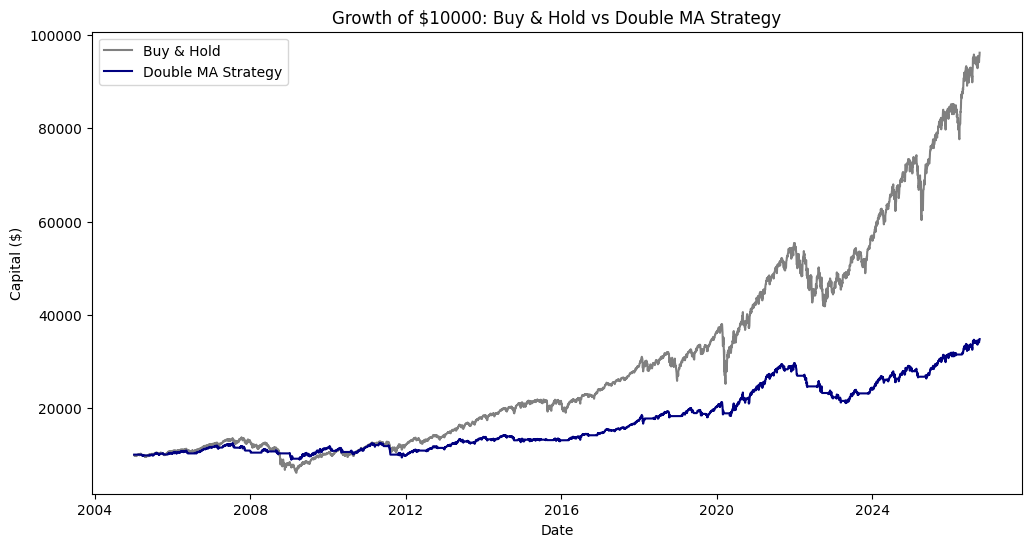

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 6))
plt.plot(data.index, data['Market_Value'], label = "Buy & Hold", color = "grey")
plt.plot(data.index, data['Strategy_Value'], label = "Double MA Strategy", color = "navy")
plt.xlabel("Date")
plt.ylabel("Capital ($)")
plt.legend()
plt.title(f"Growth of ${capital}: Buy & Hold vs Double MA Strategy")
plt.show()

**Trading costs.** Every buy or sell is charged 0.05% (5 basis points). `trade` is 1 on days the position changes and 0 otherwise.

In [12]:
cost_per_trade = 0.0005                                   # 5 bps
data['trade'] = data['position'].diff().abs()             # 1 when you enter or exit
data['strat_ret_net'] = data['strat_ret'] - data['trade'] * cost_per_trade

**Equity Curve Strategy**: “If I followed my trading strategy, how would my money have grown over time?”

**Benchmark**: “What if I had just bought the asset at the beginning and never traded it?”

In [13]:
data['equity'] = (1 + data['strat_ret_net']).cumprod()
data['equity_bh'] = (1 + data['ret']).cumprod()           # buy-and-hold benchmark

##Features for the ML model

Each feature describes the market on a given day, using only information available at that day's close.


##Volatility

**Feature: volatility.** How much daily returns have jumped around over the last 20 days (standard deviation). High values mean a nervous, bumpy market.

In [14]:
data['volatility_20d'] = data['ret'].rolling(20).std()

### Moving Average Ratio

**Feature: moving-average ratio.** How far the 20-day average is above (+) or below (−) the 50-day average, as a percentage. It contains the same information as the crossover signal, but as a number instead of yes/no.

In [15]:
data['sma_ratio'] = data['sma_fast'] / data['sma_slow'] - 1

### RSI (Relative Strength Index)

**Feature: RSI.** A 0–100 score comparing recent gains with recent losses over 14 days. Above ~70 means the price has risen a lot recently; below ~30 means it has fallen a lot.

In [16]:
delta = data['Adj Close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

data['rsi'] = 100 - (100 / (1 + rs))


### Volume

**Feature: volume ratio.** Today's trading volume divided by the 20-day average. Above 1 means unusually heavy trading.

In [17]:
data['volume_ratio'] = (
    data['Volume'] /
    data['Volume'].rolling(20).mean()
)

**Features: price vs averages and momentum.**
- `price_sma20`, `price_sma50`: how far today's price is above or below each average, in percent.
- `ret_5d`, `ret_20d`: the price change over the last 5 and 20 days.

Every feature is a percentage or ratio rather than a raw price. A raw price like 700 never appears in the early training years, so a model can't learn from it; "3% above the 20-day average" means the same thing in 2008 and in 2026.

In [18]:
data['price_sma20'] = data['Adj Close'] / data['sma_fast'] - 1
data['price_sma50'] = data['Adj Close'] / data['sma_slow'] - 1

data['ret_5d'] = data['Adj Close'].pct_change(5, fill_method=None)
data['ret_20d'] = data['Adj Close'].pct_change(20, fill_method=None)


**Target: what the model tries to predict.** The return over the next 5 trading days. It uses future prices, so it is only ever the answer the model is graded on, never one of its inputs.

In [19]:
data['target']= data['Adj Close'].shift(-5) / data['Adj Close'] - 1

In [20]:
data.head()

Price,Adj Close,Close,High,Low,Open,Volume,sma_fast,sma_slow,signal,position,...,equity_bh,volatility_20d,sma_ratio,rsi,volume_ratio,price_sma20,price_sma50,ret_5d,ret_20d,target
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,80.973534,120.300003,121.760002,119.900002,121.559998,55748000,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.010806
2005-01-04,79.984039,118.830002,120.540001,118.440002,120.459999,69167600,NaN,NaN,0,0.0,...,0.987780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.005470
2005-01-05,79.432144,118.010002,119.250000,118.000000,118.739998,65667300,NaN,NaN,0,0.0,...,0.980964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004745
2005-01-06,79.835983,118.610001,119.150002,118.260002,118.440002,47814700,NaN,NaN,0,0.0,...,0.985952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008346
2005-01-07,79.721535,118.440002,119.230003,118.129997,118.970001,55847700,NaN,NaN,0,0.0,...,0.984538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001688


## Out-of-Sample Testing

**The model pipeline, written as two functions so it can run on any ETF.**

`make_features(px)` takes a price series and builds every feature above plus the 5-day target.

`walk_forward(d)` trains and tests XGBoost the honest way:
1. `TimeSeriesSplit` cuts history into 5 test periods (2008–2012, 2012–2015, 2015–2019, 2019–2023, 2023–2026). For each one, the model trains **only on earlier years**. `gap=H` leaves 5 days between training and testing, because each target looks 5 days ahead.
2. The last 20% of each training period is held back for **early stopping**: the model keeps adding trees only while its error on that held-back slice improves. The test period is never used for this.
3. The most extreme 1% of returns on each side are clipped during training so a few crash days don't dominate.
4. For each test period it reports:
   - **IC**: correlation between predictions and what actually happened. 0 = no skill.
   - **IC_no_ovl**: the same, using every 5th day only, so the 5-day windows don't overlap and count the same move several times.
   - **R2_oos(%)**: how much better the model predicts than simply guessing the average past return. Negative means worse than that simple guess.
   - **acc vs base**: how often the predicted direction was right, next to how often "always guess up" would be right.

*Known issue:* `reg_alpha=1.0` is large compared with 5-day returns (around 0.02), so it can shrink the model's output to a constant. That is what happened in TLT's first test period (IC = NaN, best_iter = 0).

In [21]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from scipy.stats import spearmanr


x_col = ['volatility_20d','rsi', 'sma_ratio', 'price_sma20', 'price_sma50', 'ret_5d', 'ret_20d']
H = 5
ES_FRAC = 0.2

def make_features(px):

  d = pd.DataFrame(index=px.index)
  ret, fast, slow = px.pct_change(fill_method=None), px.rolling(20).mean(), px.rolling(50).mean()
  delta = px.diff()
  rs = delta.clip(lower=0).rolling(14).mean() / (-delta.clip(upper=0)).rolling(14).mean()
  d['volatility_20d']= ret.rolling(20).std()
  d['rsi']= 100 - (100 / (1 + rs))
  d['sma_fast']=  fast
  d['sma_slow']=  slow
  d['sma_ratio'] = fast / slow - 1
  d['price_sma20'] = px / fast - 1
  d['price_sma50'] = px / slow - 1
  d['ret_5d'] = px.pct_change(5, fill_method=None)
  d['ret_20d'] = px.pct_change(20, fill_method=None)
  d['target']= px.shift(-5) / px - 1
  d = d.dropna()
  return d


def walk_forward(d, seed=42):
  X = d[x_col]
  y = d['target']

  tscv = TimeSeriesSplit(n_splits=5, gap=H)
  scores, oos_pred= [], []


  for tr,va in tscv.split(X):

    n_es = int(len(tr) * ES_FRAC)
    fit_idx = tr[:-(n_es + H)]
    es_idx = tr[-n_es:]


    X_fit, y_fit = X.iloc[fit_idx], y.iloc[fit_idx]
    X_es,  y_es  = X.iloc[es_idx],  y.iloc[es_idx]
    X_val, y_val = X.iloc[va],      y.iloc[va]

    lo,hi = y_fit.quantile([0.01,0.99])

    model = xgb.XGBRegressor(
          objective='reg:squarederror',  # 노이즈에 견고 (또는 reg:squarederror, pseudohubererror)
          n_estimators=1000,
          learning_rate=0.02,
          max_depth=3,   # 트리 깊이 (level-wise)
          min_child_weight=50,
          subsample=0.8,            # 행 샘플링
          colsample_bytree=0.8,     # 열 샘플링
          reg_alpha=1.0,            # L1 정규화
          tree_method='hist',       # 빠른 히스토그램 방식
          eval_metric='rmse',
          early_stopping_rounds=100,
          random_state=42,
    )
    model.fit(X_fit,y_fit.clip(lo,hi),
              eval_set=[(X_es,y_es.clip(lo,hi))],
              verbose=False)

    #-------- predict ------------
    pred = pd.Series(model.predict(X_val),index=X_val.index)
    oos_pred.append(pred)

    #-------- Nothing ------------
    mu = y_fit.mean()
    sse = ((y_val - pred) ** 2).sum()
    sse0 = ((y_val - mu) ** 2).sum()
    acc = (np.sign(pred) == np.sign(y_val)).mean()

    scores.append(
      {
          'test_start' : X_val.index[0],
          'test_end' : X_val.index[-1],
          'IC': spearmanr(pred, y_val).correlation,
          'IC_no_ovl': spearmanr(pred.iloc[::H],y_val.iloc[::H]).correlation,
          'R2_oos(%)': 100 * (1 - sse/sse0),
          'acc': (np.sign(pred) == np.sign(y_val)).mean(),
          'base': (y_val>0).mean(),
          'best_iter': model.best_iteration,
          'best_score': model.best_score,
          'rmse': np.sqrt(mean_squared_error(y_val, pred)),
      }
  )



  print(pd.DataFrame(scores).round(3))






*(English)* SPY and QQQ are large US companies, EFA is developed markets outside the US, IWM is small US companies, TLT is long-term US government bonds, and GLD is gold. The idea was to see whether the model works on different kinds of assets, not just SPY.


**Run the pipeline on six ETFs.** Each ETF is downloaded, turned into features, and passed through the same walk-forward test, so the results are directly comparable.


In [22]:
symbol_list = ['SPY', 'QQQ', 'EFA', 'IWM', 'TLT','GLD']
for tk in symbol_list:
  raw = yf.download(tk, start="2005-01-01", auto_adjust=False)
  if isinstance(raw.columns,pd.MultiIndex):
    raw.columns = raw.columns.droplevel(1)
  d = make_features(raw['Adj Close'].dropna())
  print(f"------{tk} ---------------")
  walk_forward(d)

[*********************100%***********************]  1 of 1 completed


------SPY ---------------
  test_start   test_end     IC  IC_no_ovl  R2_oos(%)    acc   base  best_iter  \
0 2008-10-16 2012-05-16  0.072      0.094      0.031  0.581  0.581        100   
1 2012-05-17 2015-12-17  0.083      0.060      0.836  0.617  0.612         38   
2 2015-12-18 2019-07-23  0.009      0.003     -2.686  0.557  0.632        335   
3 2019-07-24 2023-02-22  0.019      0.106      0.127  0.596  0.596         30   
4 2023-02-23 2026-09-29  0.098      0.068      1.136  0.621  0.621         66   

   best_score   rmse  
0       0.024  0.033  
1       0.025  0.017  
2       0.017  0.018  
3       0.017  0.030  
4       0.025  0.019  


[*********************100%***********************]  1 of 1 completed


------QQQ ---------------
  test_start   test_end     IC  IC_no_ovl  R2_oos(%)    acc   base  best_iter  \
0 2008-10-16 2012-05-16  0.016      0.057      0.043  0.599  0.599          0   
1 2012-05-17 2015-12-17  0.073      0.063      0.259  0.609  0.609          3   
2 2015-12-18 2019-07-23  0.016     -0.028     -0.422  0.578  0.622        218   
3 2019-07-24 2023-02-22  0.062      0.083      0.172  0.588  0.586         95   
4 2023-02-23 2026-09-29  0.114      0.084      1.347  0.608  0.606        213   

   best_score   rmse  
0       0.032  0.033  
1       0.028  0.020  
2       0.021  0.023  
3       0.022  0.035  
4       0.032  0.026  


[*********************100%***********************]  1 of 1 completed


...

------IWM ---------------
  test_start   test_end     IC  IC_no_ovl  R2_oos(%)    acc   base  best_iter  \
0 2008-10-16 2012-05-16  0.003      0.002     -0.054  0.563  0.563         30   
1 2012-05-17 2015-12-17  0.110      0.027      0.125  0.579  0.579          2   
2 2015-12-18 2019-07-23  0.008     -0.042     -2.964  0.540  0.568        476   
3 2019-07-24 2023-02-22  0.008      0.107     -0.300  0.547  0.540         37   
4 2023-02-23 2026-09-29  0.053      0.031      0.296  0.529  0.529         22   

   best_score   rmse  
0       0.030  0.043  
1       0.034  0.021  
2       0.021  0.024  
3       0.022  0.040  
4       0.034  0.028  


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1231/2466694517.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'IC': spearmanr(pred, y_val).correlation,
/tmp/ipykernel_1231/2466694517.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'IC_no_ovl': spearmanr(pred.iloc[::H],y_val.iloc[::H]).correlation,


------TLT ---------------
  test_start   test_end     IC  IC_no_ovl  R2_oos(%)    acc   base  best_iter  \
0 2008-10-16 2012-05-16    NaN        NaN     -0.002  0.548  0.548          0   
1 2012-05-17 2015-12-17  0.032      0.056      0.023  0.529  0.529        118   
2 2015-12-18 2019-07-23 -0.041     -0.041     -1.341  0.547  0.549        445   
3 2019-07-24 2023-02-22  0.013      0.033      0.104  0.502  0.502         12   
4 2023-02-23 2026-09-29 -0.038     -0.048      0.104  0.473  0.473         15   

   best_score   rmse  
0       0.015  0.025  
1       0.022  0.018  
2       0.017  0.015  
3       0.014  0.023  
4       0.021  0.019  


[*********************100%***********************]  1 of 1 completed


------GLD ---------------
  test_start   test_end     IC  IC_no_ovl  R2_oos(%)    acc   base  best_iter  \
0 2008-10-16 2012-05-16 -0.018      0.011      0.002  0.592  0.592          3   
1 2012-05-17 2015-12-17  0.121      0.115     -3.240  0.482  0.477        256   
2 2015-12-18 2019-07-23  0.020      0.031     -0.962  0.522  0.532        263   
3 2019-07-24 2023-02-22  0.067      0.086      0.519  0.522  0.554        128   
4 2023-02-23 2026-09-29  0.015      0.089     -0.047  0.586  0.585         46   

   best_score   rmse  
0       0.035  0.028  
1       0.026  0.024  
2       0.020  0.017  
3       0.016  0.023  
4       0.022  0.028  


**Same test written out for SPY only.** This is the step-by-step version of `walk_forward()` run on the `data` table built earlier. Its results match the SPY block above, which is a useful check that the function and the long version agree.

In [23]:


# X: 20-day SMA = data['sma_fast']
# X: 50-day SMA = data['sma_slow']
# X: 20-day Volatility = data['volatility_20d']
# X: Relative Strength Index (RSI) = data['rsi']

# Y: Target = data['target']



sub = data[x_col + ['target']].dropna()
X = sub[x_col]
y = sub['target']



tscv = TimeSeriesSplit(n_splits=5, gap=H)
scores, oos_pred= [], []


for tr,va in tscv.split(X):
  '''
  cut = int(len(tr) - H)
  fit_idx = tr[:cut - H]
  es_idx = tr[cut:]
  '''
  n_es = int(len(tr) * ES_FRAC)
  fit_idx = tr[:-(n_es + H)]
  es_idx = tr[-n_es:]


  X_fit, y_fit = X.iloc[fit_idx], y.iloc[fit_idx]
  X_es,  y_es  = X.iloc[es_idx],  y.iloc[es_idx]
  X_val, y_val = X.iloc[va],      y.iloc[va]

  lo,hi = y_fit.quantile([0.01,0.99])

  model = xgb.XGBRegressor(
        objective='reg:squarederror',  # 노이즈에 견고 (또는 reg:squarederror, pseudohubererror)
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=3,   # 트리 깊이 (level-wise)
        min_child_weight=50,
        subsample=0.8,            # 행 샘플링
        colsample_bytree=0.8,     # 열 샘플링
        reg_alpha=1.0,            # L1 정규화
        tree_method='hist',       # 빠른 히스토그램 방식
        eval_metric='rmse',
        early_stopping_rounds=100,
        random_state=42,
  )
  model.fit(X_fit,y_fit.clip(lo,hi),
            eval_set=[(X_es,y_es.clip(lo,hi))],
            verbose=False)

  #-------- predict ------------
  pred = pd.Series(model.predict(X_val),index=X_val.index)
  oos_pred.append(pred)

  #-------- Nothing ------------
  mu = y_fit.mean()
  sse = ((y_val - pred) ** 2).sum()
  sse0 = ((y_val - mu) ** 2).sum()
  acc = (np.sign(pred) == np.sign(y_val)).mean()

  scores.append(
    {
        'test_start' : X_val.index[0],
        'test_end' : X_val.index[-1],
        'IC': spearmanr(pred, y_val).correlation,
        'IC_no_ovl': spearmanr(pred.iloc[::H],y_val.iloc[::H]).correlation,
        'R2_oos(%)': 100 * (1 - sse/sse0),
        'acc': (np.sign(pred) == np.sign(y_val)).mean(),
        'base': (y_val>0).mean(),
        'best_iter': model.best_iteration,
        'best_score': model.best_score,
        'rmse': np.sqrt(mean_squared_error(y_val, pred)),
    }
)



print(pd.DataFrame(scores).round(3))




  test_start   test_end     IC  IC_no_ovl  R2_oos(%)    acc   base  best_iter  \
0 2008-10-16 2012-05-16  0.072      0.094      0.031  0.581  0.581        100   
1 2012-05-17 2015-12-17  0.083      0.060      0.836  0.617  0.612         38   
2 2015-12-18 2019-07-23  0.006     -0.010     -4.067  0.553  0.632        621   
3 2019-07-24 2023-02-22  0.019      0.108      0.127  0.596  0.596         30   
4 2023-02-23 2026-09-29  0.097      0.066      1.125  0.621  0.621         66   

   best_score   rmse  
0       0.024  0.033  
1       0.025  0.017  
2       0.017  0.018  
3       0.017  0.030  
4       0.025  0.019  


**How big are 5-day moves?** The average 5-day return is about +0.24%, but the typical swing around that average (standard deviation) is about 2.4%, roughly 10 times larger. The pattern the model is looking for is tiny compared with the noise around it. This is the core problem explained in the Limitations section.

In [24]:
print(y.describe())

count    5420.000000
mean        0.002378
std         0.023934
min        -0.197933
25%        -0.008071
50%         0.004012
75%         0.014844
max         0.194036
Name: target, dtype: float64


**Early classifier attempt (kept for the record; not used in the conclusions).** This tried predicting tomorrow's up/down direction with `XGBClassifier`. It has several problems that were fixed in the regression pipeline above:
- it uses raw moving-average prices (`sma_fast`, `sma_slow`) as features;
- it predicts 1 day ahead instead of 5, so it can't be compared with the regressor;
- `gamma=0.1` and `reg_alpha=0.5` are too strict for such small targets;
- early stopping watches the test period;
- the prediction part reuses the regressor's `model` and appends to the old `scores` list, which is why rows 5–9 of the output repeat the same numbers.

The validation logloss rises from the first round in every fold (about 0.687 → 0.70+), meaning each added tree made predictions on new data slightly worse.

In [26]:
data['target_class'] = (data['ret'].shift(-1) > 0).astype(int)
x_col = ['sma_fast','sma_slow','volatility_20d','rsi', 'volume_ratio']
sub_class = data[x_col + ['target_class']].dropna()
X_class = sub_class[x_col]
y_class = sub_class['target_class']

tscv = TimeSeriesSplit(n_splits=5, gap=5)
scores_class = [] # Using a new list for classification scores

for tr,va in tscv.split(X_class):
  X_train_class, X_val_class = X_class.iloc[tr], X_class.iloc[va]
  y_train_class, y_val_class = y_class.iloc[tr], y_class.iloc[va]

  model_class = xgb.XGBClassifier(  # Changed to XGBClassifier
        objective='binary:logistic',  # Objective for binary classification
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        gamma=0.1,
        tree_method='hist',
        early_stopping_rounds=100,
        eval_metric='logloss',  # Evaluation metric for classification
        random_state=42,
  )
  model_class.fit(X_train_class, y_train_class,
            eval_set=[(X_val_class, y_val_class)],
            verbose=100)
  scores_class.append(model_class.best_score)

    #-------- predict ------------
  pred = model.predict(X_val)
  scores.append(
      {
          'test_start' : X_val.index[0],
          'test_end' : X_val.index[-1],
          'IC': spearmanr(pred, y_val).correlation,
          'acc': (np.sign(pred) == np.sign(y_val)).mean(),
          'base': (y_val>0).mean(),
          'best_iter': model.best_iteration,
          'best_score': model.best_score,
          'rmse': mean_squared_error(y_val, pred),
      }
  )

print(pd.DataFrame(scores).round(3))

[0]	validation_0-logloss:0.68809
[100]	validation_0-logloss:0.68927
[128]	validation_0-logloss:0.69170
[0]	validation_0-logloss:0.68688
[100]	validation_0-logloss:0.70543
[104]	validation_0-logloss:0.70732
[0]	validation_0-logloss:0.68705
[100]	validation_0-logloss:0.72453
[102]	validation_0-logloss:0.72662
[0]	validation_0-logloss:0.69113
[100]	validation_0-logloss:0.69471
[0]	validation_0-logloss:0.68572
[100]	validation_0-logloss:0.70401
  test_start   test_end     IC  IC_no_ovl  R2_oos(%)    acc   base  best_iter  \
0 2008-10-16 2012-05-16  0.072      0.094      0.031  0.581  0.581        100   
1 2012-05-17 2015-12-17  0.083      0.060      0.836  0.617  0.612         38   
2 2015-12-18 2019-07-23  0.006     -0.010     -4.067  0.553  0.632        621   
3 2019-07-24 2023-02-22  0.019      0.108      0.127  0.596  0.596         30   
4 2023-02-23 2026-09-29  0.097      0.066      1.125  0.621  0.621         66   
5 2023-02-23 2026-09-29  0.097        NaN        NaN  0.621  0.621   

# Results

Across 6 ETFs × 5 test periods = **30 out-of-sample tests**:

| ETF | Avg IC | Avg IC (no overlap) | Avg R² vs. historical mean |
|---|---|---|---|
| SPY | 0.055 | 0.045 | −0.15% |
| QQQ | 0.059 | 0.068 | +0.28% |
| EFA | −0.011 | 0.019 | −1.62% |
| IWM | 0.033 | 0.014 | −0.78% |
| TLT | −0.001 | −0.019 | −0.22% |
| GLD | 0.041 | 0.037 | −0.82% |

What this shows:
- **The model almost never beat "always guess up."** Its directional accuracy equalled the base rate in 19 of 30 tests (it was predicting "up" nearly every day), was lower in 8, and higher in only 3, by at most 0.8 percentage points.
- **It predicted no better than the historical average.** Average out-of-sample R² was negative for 5 of the 6 ETFs, meaning that guessing "the usual 5-day return" every week would have been about as good or better.
- **The small positive IC for SPY and QQQ is not reliable.** It changes size and sometimes sign between the overlapping and non-overlapping versions, and between test periods. When I ran the same pipeline on randomly generated prices with no pattern at all, individual test periods still showed IC values of 0.066 and 0.092 purely by chance.

**Conclusion:** with price-based features, neither the crossover nor the ML model gives a reliable way to time these ETFs. Buy-and-hold was the strongest of the approaches tested.

# Limitations: why this approach doesn't work well

**1. The signal is tiny compared with the noise.** SPY's average 5-day return is about +0.24%, but its typical swing is about 2.4%. Even large research studies find that the best machine-learning models explain well under 1% of monthly stock return variation: Gu, Kelly & Xiu (2020) report out-of-sample R² of roughly 0.33–0.40% for trees and neural networks, using over 900 predictors. My R² values, between about −8% and +1.3%, are in line with that.

**2. Well-known predictors stop working out of sample.** Welch & Goyal (2008) tested the variables that published research claimed could predict the stock market and found that none would have beaten simply using the historical average return in real time, and most would have done worse.

**3. Markets adapt once a pattern is known.** McLean & Pontiff (2016) studied 97 published stock-return predictors: their returns were 26% lower after the original study period and 58% lower after publication, as investors traded on them. Moving averages, RSI and momentum are among the most widely used indicators, so any edge in them is heavily competed for.

**4. Trying many versions makes luck look like skill.** Each new setting, feature, ETF or horizon I test is another chance for a random pattern to look real. Bailey, Borwein, López de Prado & Zhu show that the more configurations are tried, the more likely the best-looking backtest is overfit. Sullivan, Timmermann & White (1999) found the same for moving-average trading rules: the best rule chosen using data up to 1986 did not keep outperforming afterwards. As Elliott (2021, ch. 3) points out, genuinely random sequences contain streaks that people read as patterns.

**5. Market behaviour changes over time.** The model's results swing between periods (for example, EFA's 2012–2015 period had IC −0.15 and R² −8.1%), so a pattern learned from 2005–2012 may not apply in 2015–2019. López de Prado (2018) lists low signal-to-noise and changing (non-stationary) data among the main reasons machine-learning funds fail.

**6. Accuracy is misleading.** SPY rose over 5 days in roughly 58–63% of test weeks, so a model that always says "up" already scores ~60%. A model must beat that base rate, not 50%, to have shown anything.

**7. Fewer independent data points than it seems.** Each target overlaps the next four days, so 21 years of daily data contain only about 1,100 independent 5-day periods, split further across 5 test periods.

**8. One ETF gives very few bets.** About "quants only being right 50% of the time": Renaissance's Medallion fund was reportedly right on about 50.75% of its trades, but it made millions of trades across thousands of positions with very low costs and leverage. Grinold's Fundamental Law of Active Management captures this: risk-adjusted skill ≈ IC × √(number of independent bets). A small edge only becomes profitable when it is applied many times. Timing a single ETF once a week provides far too few bets, and each trade pays costs.

**9. Price-only information is public.** Every feature here is derived from past prices and volume, which every market participant already sees.

**What I would change if I continued:** compare against a simple logistic-regression baseline, convert predictions into an actual backtest on the same dates as the crossover, add information that is not just past prices (VIX, interest rates), and count how many versions I tried so the final result can be judged fairly.

# Next project: screening risky stocks and a portfolio tracker

The main lesson is that **predicting whether a price will go up is very hard, but predicting how risky an asset will be is much easier.** Volatility tends to cluster: calm periods follow calm periods and turbulent periods follow turbulent ones. Moreira & Muir (2017) show that variance is highly forecastable up to about a year ahead, while those forecasts say little about future returns. In this project, `volatility_20d` was a feature for predicting direction; in the next one, risk becomes the thing being measured directly.

**Planned idea:**
1. **Screen out high-risk stocks** using measures such as volatility, maximum drawdown, beta (how much a stock moves with the market) and trading liquidity, producing a curated list.
2. **A portfolio website** where users choose stocks from that list, see each one's risk profile, and evaluate how their combined portfolio behaves (overall volatility, diversification, drawdown).
3. **Year-round tracking** so users can monitor and rebalance their portfolio as risk levels change.

The aim shifts from "beat the market" to "help people understand and manage the risk they're taking," which is better supported by the evidence. Because it involves people's investment choices, the site should be presented as an educational tool rather than financial advice.

# Sources

- Gu, Kelly & Xiu (2020), *Empirical Asset Pricing via Machine Learning*, Review of Financial Studies. [NBER paper](https://www.nber.org/papers/w25398.pdf) · [summary of results](https://www.research-center.mirova.com/en/research-library/Empirical-Asset-Pricing-via-Machine-Learning)
- Welch & Goyal (2008), *A Comprehensive Look at the Empirical Performance of Equity Premium Prediction*, Review of Financial Studies. [NBER](https://nber.org/papers/w10483)
- McLean & Pontiff (2016), *Does Academic Research Destroy Stock Return Predictability?*, Journal of Finance. [CFA Institute digest](https://rpc.cfainstitute.org/research/cfa-digest/2016/06/does-academic-research-destroy-stock-return-predictability-digest-summary)
- Bailey, Borwein, López de Prado & Zhu, *The Probability of Backtest Overfitting*, Journal of Computational Finance. [SSRN](https://papers.ssrn.com/abstract=2326253)
- Sullivan, Timmermann & White (1999), *Data-Snooping, Technical Trading Rule Performance, and the Bootstrap*, Journal of Finance. [LSE](https://researchonline.lse.ac.uk/id/eprint/119144)
- López de Prado (2018), *The 10 Reasons Most Machine Learning Funds Fail*, Journal of Portfolio Management. [GARP](https://www.garp.org/hubfs/Whitepapers/a1Z1W0000054x6lUAA.pdf)
- Grinold's Fundamental Law of Active Management. [Eaton Vance explainer](https://eatonvance.com/content/dam/im/assets/publication/thought-leadership/consilient-observer/dispersion-and-alpha-conversion.pdf)
- Medallion fund's ~50.75% win rate (from Zuckerman, *The Man Who Solved the Market*, 2019). [Institutional Investor](https://www.institutionalinvestor.com/index%2ephp/article/2bswymr8cih3jeaslxc00/portfolio/famed-medallion-fund-stretches-explanation-to-the-limit-professor-claims)
- Moreira & Muir (2017), *Volatility-Managed Portfolios*, Journal of Finance. [NBER](https://www.nber.org/papers/22208)
- Elliott (2021), *What Are the Chances of That?*, Oxford University Press, Chapter 3 "Random Thoughts".